In [68]:
import pandas as pd
import numpy as np
import sklearn.linear_model 

# Data procesing 

In [69]:
patients = pd.read_csv("patients.csv")
dignoses = pd.read_csv("diagnoses.csv")
outcomes = pd.read_csv("outcomes.csv")
labs = pd.read_csv("labs.csv")


In [70]:
patients = patients.merge(dignoses, on = "DiagnosisID")
patients = patients.merge(outcomes, on = "OutcomeID")

In [71]:
patients["AdmissionDate"] = pd.to_datetime(patients["AdmissionDate"])
patients['DischargeDate']= pd.to_datetime(patients['DischargeDate'])
patients['lenghofsay']= (patients["DischargeDate"]-patients["AdmissionDate"])
# This extracts just the integer number of days from the timedelta
patients['lenghofsay'] = patients['lenghofsay'].dt.days
patients['lenghofsay']

0       13
1        2
2       64
3        2
4        1
      ... 
195      4
196    124
197      9
198      9
199     57
Name: lenghofsay, Length: 200, dtype: int64

In [72]:
patients["outcomeEncoded"] = patients["OutcomeName"].map({'Recovered' : 0, 'Complicated' : 1 ,'Deceased' : 1})

In [73]:
patients['HighRisk'] = np.where((patients["Age"]>65) | (patients["OutcomeName"].isin(["Complicated","Deceased"])),1,0)

In [74]:
abnormal_condition = {
    "Blood sugar" : lambda x : X>120,
    "Cholestrol": lambda x:x>200,
    "Hemoglobin": lambda x: x<13
}

def count_abnormal_labs(patient_id):
    patient_lab = labs[labs["PatientID"]== patient_id]
    count = 0
    for test_name, condition in abnormal_condition.items():
        test_result = patient_lab[patient_lab["TestName"]== test_name]
        count += test_result["Result"].apply(condition).sum()
    return count

patients["AbnormalLabcount"] = patients["PatientID"].apply(count_abnormal_labs)

## Model traning

In [75]:
fetures = patients[["Age","lenghofsay","TreatmentCost","AbnormalLabcount"]]
Target = patients["outcomeEncoded"]

In [76]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(fetures,Target, test_size =0.3,random_state = 42)

### 
* supervise  input + output - linerRegrations,logistic regression etc
* unsupervise - input 
* reinforcment - rewards

In [78]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=500)
model.fit(x_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,500
,multi_class,'deprecated'


In [79]:
from sklearn.metrics import classification_report,confusion_matrix
y_pred= model.predict(x_test)
print("classification report")
print(classification_report(y_test, y_pred))


classification report
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        17
           1       0.72      1.00      0.83        43

    accuracy                           0.72        60
   macro avg       0.36      0.50      0.42        60
weighted avg       0.51      0.72      0.60        60



C:\Users\monkey\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\monkey\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\monkey\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


# roc curve

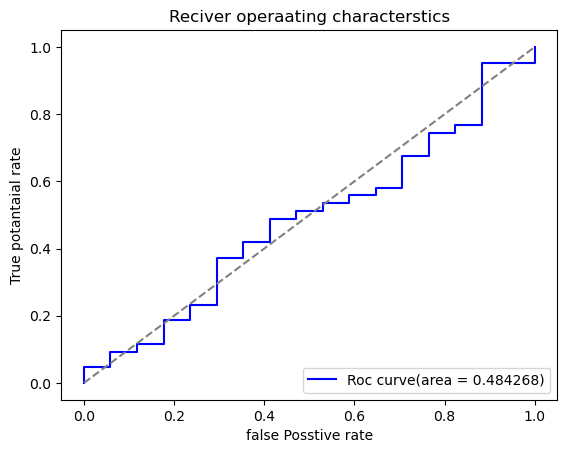

In [88]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve,auc

y_pred = model.predict_proba(x_test)[:,1]
fpr,tpr, thresholds = roc_curve(y_test,y_pred)
roc_aur = auc(fpr,tpr)

plt.figure()
plt.plot(fpr,tpr,color = "blue",label= f'Roc curve(area = {roc_aur:2f})')
plt.plot([0,1],[0,1], color  = "gray", linestyle = "--")
plt.xlabel("false Posstive rate")
plt.ylabel("True potantaial rate")
plt.title("Reciver operaating characterstics")
plt.legend(loc="lower right");
          

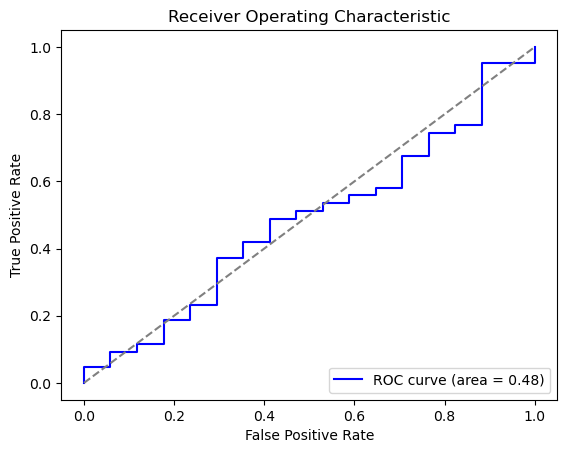

In [87]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Get prediction probabilities for the positive class
y_pred = model.predict_proba(x_test)[:, 1]

# Calculate False Positive Rate, True Positive Rate, and Thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_pred)

# Calculate Area Under the Curve (AUC) - Fixed variable name to roc_auc
roc_auc = auc(fpr, tpr)

# Generate the plot
plt.figure()

# Fixed the decimal formatting in the label
plt.plot(fpr, tpr, color="blue", label=f'ROC curve (area = {roc_auc:.2f})')

# Fixed the typo (plt.plot) and the coordinates for the diagonal line
plt.plot([0, 1], [0, 1], color="gray", linestyle="--")

# Fixed the spelling in the labels and title
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

# Fixed the typo (plt.title) and spelling
plt.title("Receiver Operating Characteristic")

# Fixed the syntax error (equals sign instead of hyphen)
plt.legend(loc="lower right")

# Display the graph
plt.show()

In [89]:
import joblib
joblib.dump(model, "Risk_model1.ipynb")

['Risk_model1.ipynb']

In [91]:
pip  install streamlit

Note: you may need to restart the kernel to use updated packages.


In [4]:
import streamlit as st
import pandas as pd
import joblib 
model = joblib.load('Risk_model1.ipynb')
st.title("Healthcare Risk")
age = st.number_input("Age", min_value = 0)
length_Of_stay = st.number_input("Length of the saty(days)", min_value = 0)
treatment_cost = st.number_input("Treatment Cost", min_value=0.0)

if st.button("Predict"):
    input_data = pd.DataFrame([[age,lenght_of_stay,treatment_cost]], columns=['Age',"lenghofsay","TreatmentCost"])
    prediction = model.predict(input_data)[0]
    probability = model .predict_proba(input_data)[0][1]

    st.write(f'Risk prediction: {"High Risk"if prediction == 1 else 'Low Risk'}')
    st.write(f"Risk probability: {round(probability,2)}")

2026-05-23 11:32:51.874 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-23 11:32:51.875 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-23 11:32:51.876 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-23 11:32:51.877 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-23 11:32:51.877 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-23 11:32:51.878 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-23 11:32:51.879 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-23 11:32:51.881 Session state does not function when running a script without `streamlit run`
2026-05-23 11:32

In [5]:
import joblib

# Assuming your trained model variable is named 'model'
joblib.dump(model, 'Risk_model.pkl')

['Risk_model.pkl']

In [1]:
import streamlit as st
import pandas as pd
import joblib 

# 1. Load the correctly saved .pkl model file
model = joblib.load('Risk_model.pkl')

st.title("Healthcare Risk Predictor")

# 2. Collect all 4 required inputs
age = st.number_input("Age", min_value=0)
length_of_stay = st.number_input("Length of stay (days)", min_value=0)
treatment_cost = st.number_input("Treatment Cost", min_value=0.0)
abnormal_lab_count = st.number_input("Abnormal Lab Count", min_value=0) # Added missing feature

if st.button("Predict"):
    # 3. Build the DataFrame exactly as the model expects it
    input_data = pd.DataFrame(
        [[age, length_of_stay, treatment_cost, abnormal_lab_count]], 
        columns=["Age", "lenghofsay", "TreatmentCost", "AbnormalLabcount"]
    )
    
    # 4. Make predictions
    prediction = model.predict(input_data)[0]
    probability = model.predict_proba(input_data)[0][1]

    # 5. Display results (Fixed formatting and capitalization)
    st.write(f'Risk prediction: {"High Risk" if prediction == 1 else "Low Risk"}')
    st.write(f"Risk probability: {round(probability, 2)}")

2026-05-23 11:54:15.359 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-23 11:54:16.176 
  command:

    streamlit run C:\Users\monkey\anaconda3\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-05-23 11:54:16.177 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-23 11:54:16.177 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-23 11:54:16.178 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-23 11:54:16.180 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-23 11:54:16.181 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-23 11:54:16.181 Thread 'MainThread': m

In [2]:
streamlit run C:\Users\monkey\anaconda3\Lib\site-packages\ipykernel_launcher.py

SyntaxError: invalid syntax (1660422050.py, line 1)